In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/spaceship-titanic/sample_submission.csv
/kaggle/input/spaceship-titanic/train.csv
/kaggle/input/spaceship-titanic/test.csv


In [2]:
data=pd.read_csv('/kaggle/input/spaceship-titanic/train.csv')

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [4]:
data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [5]:
df=data.copy()
df.describe(include='all')

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
count,8693,8492,8476,8494,8511,8514.000000,8490,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000,8493,8693
unique,8693,3,2,6560,3,NaN,2,NaN,NaN,NaN,NaN,NaN,8473,2
top,0001_01,Earth,False,G/734/S,TRAPPIST-1e,NaN,False,NaN,NaN,NaN,NaN,NaN,Gollux Reedall,True
freq,1,4602,5439,8,5915,NaN,8291,NaN,NaN,NaN,NaN,NaN,2,4378
mean,NaN,NaN,NaN,NaN,NaN,28.827930,NaN,224.687617,458.077203,173.729169,311.138778,304.854791,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,14.489021,NaN,666.717663,1611.489240,604.696458,1136.705535,1145.717189,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,19.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,27.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,38.000000,NaN,47.000000,76.000000,27.000000,59.000000,46.000000,NaN,NaN


In [6]:
# Create a new DataFrame to store the preprocessed data
df_processed = pd.DataFrame()

# Iterate through the columns of the DataFrame
for column in df.columns:
  # Get the data type of the column
  dtype = df[column].dtype
  
  # Check if the column is numeric
  if dtype == 'float64' or dtype == 'int64':
    # Perform preprocessing for numeric columns
    # For example, you can fill missing values with the median of the column
    df_processed[column] = df[column].fillna(df[column].median())
  else:
    # Perform preprocessing for non-numeric columns
    # For example, you can fill missing values with the mode of the column
    # and encode the categories as integers
    df_processed[column] = df[column].fillna(df[column].mode()[0])
    df_processed[column] = pd.Categorical(df_processed[column]).codes
    
  # You can add other preprocessing steps here, such as scaling or encoding, depending on the needs of your analysis


In [7]:
df_processed.describe()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
count,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000
mean,4346.000000,0.649833,0.349362,3218.609341,1.494306,28.790291,0.022892,220.009318,448.434027,169.572300,304.588865,298.261820,4145.840561,0.503624
std,2509.597278,0.795183,0.476796,2003.884349,0.814966,14.341404,0.149568,660.519050,1595.790627,598.007164,1125.562559,1134.126417,2484.676217,0.500016
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2173.000000,0.000000,0.000000,1341.000000,1.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1967.000000,0.000000
50%,4346.000000,0.000000,0.000000,3218.000000,2.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4132.000000,1.000000
75%,6519.000000,1.000000,1.000000,5018.000000,2.000000,37.000000,0.000000,41.000000,61.000000,22.000000,53.000000,40.000000,6302.000000,1.000000
max,8692.000000,2.000000,1.000000,6559.000000,2.000000,79.000000,1.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000,8472.000000,1.000000


In [8]:
def evaluate_dataset(df):
  """
  Evaluate the quality of a preprocessed dataset for a classification problem.
  
  Parameters:
  df (pandas.DataFrame): Preprocessed dataset with features and target column.
  
  Returns:
  float: Rating of the dataset out of 10.
  """
  
  # Get the target column
  target = df.columns[-1]
  
  # Calculate the class balance
  class_counts = df[target].value_counts()
  class_balance = class_counts.max() / class_counts.sum()
  
  # Calculate the correlation between features
  corr = df.drop(target, axis=1).corr()
  
  # Calculate the missing values ratio
  missing_values = df.isnull().sum().sum() / df.size
  
  # Calculate the data quality score
  score = 10 - (class_balance + missing_values + corr.abs().mean().mean())
  
  # Print the score and suggest preprocessing steps if needed
  print(f'Data quality score: {score:.2f}/10')
  if class_balance < 0.8:
    print('The class balance is low. Consider oversampling or undersampling the minority class.')
  if missing_values > 0:
    print('There are missing values in the dataset. Consider imputing or dropping them.')
  if corr.abs().mean().mean() > 0.75:
    print('There is high correlation between some features. Consider removing correlated features or applying feature selection.')
    

In [9]:
evaluate_dataset(df_processed)

Data quality score: 9.34/10
The class balance is low. Consider oversampling or undersampling the minority class.


In [10]:
df_processed.describe(include='all')

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
count,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000
mean,4346.000000,0.649833,0.349362,3218.609341,1.494306,28.790291,0.022892,220.009318,448.434027,169.572300,304.588865,298.261820,4145.840561,0.503624
std,2509.597278,0.795183,0.476796,2003.884349,0.814966,14.341404,0.149568,660.519050,1595.790627,598.007164,1125.562559,1134.126417,2484.676217,0.500016
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2173.000000,0.000000,0.000000,1341.000000,1.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1967.000000,0.000000
50%,4346.000000,0.000000,0.000000,3218.000000,2.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4132.000000,1.000000
75%,6519.000000,1.000000,1.000000,5018.000000,2.000000,37.000000,0.000000,41.000000,61.000000,22.000000,53.000000,40.000000,6302.000000,1.000000
max,8692.000000,2.000000,1.000000,6559.000000,2.000000,79.000000,1.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000,8472.000000,1.000000


In [11]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

def balance_classes(df, target, method='oversampling'):
  """
  Balance the class distribution in a Pandas DataFrame.
  
  Parameters:
  df (pandas.DataFrame): DataFrame with features and target column.
  target (str): Name of the target column.
  method (str): Method to use for balancing the classes.
               Can be 'oversampling' (default) or 'undersampling'.
  
  Returns:
  pandas.DataFrame: DataFrame with balanced class distribution.
  """
  
  # Separate the features and target into X and y
  X = df.drop(target, axis=1)
  y = df[target]
  
  if method == 'oversampling':
    # Oversample the minority class using SMOTE
    oversampler = SMOTE(random_state=0)
    X_resampled, y_resampled = oversampler.fit_resample(X, y)
  elif method == 'undersampling':
    # Undersample the majority class using random undersampling
    undersampler = RandomUnderSampler(random_state=0)
    X_resampled, y_resampled = undersampler.fit_resample(X, y)
  else:
    raise ValueError(f'Invalid method: {method}')
  
  # Concatenate the resampled data back into a DataFrame
  df_resampled = pd.concat([X_resampled, y_resampled], axis=1)
  
  return df_resampled

# Balance the classes in the DataFrame using oversampling
df_balanced = balance_classes(df_processed, 'Transported')

# Balance the classes in the DataFrame using undersampling
df_balanced = balance_classes(df_processed, 'Transported', method='undersampling')


In [12]:
evaluate_dataset(df_balanced)

Data quality score: 9.35/10
The class balance is low. Consider oversampling or undersampling the minority class.


In [13]:
df_balanced.describe(include='all')

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
count,8630.000000,8630.000000,8630.000000,8630.000000,8630.000000,8630.000000,8630.000000,8630.000000,8630.000000,8630.000000,8630.000000,8630.000000,8630.000000,8630.000000
mean,4345.355504,0.649710,0.347972,3219.033024,1.493511,28.803476,0.022943,220.836269,446.621553,170.004635,306.472654,299.677173,4142.189919,0.500000
std,2511.407590,0.795607,0.476355,2001.814952,0.815252,14.349109,0.149731,661.534492,1592.302557,598.892053,1129.376269,1137.842640,2484.188818,0.500029
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2170.250000,0.000000,0.000000,1347.000000,1.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1961.250000,0.000000
50%,4341.500000,0.000000,0.000000,3218.500000,2.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4126.500000,0.500000
75%,6523.750000,1.000000,1.000000,5016.750000,2.000000,37.000000,0.000000,42.000000,61.000000,23.000000,54.750000,40.000000,6299.750000,1.000000
max,8692.000000,2.000000,1.000000,6559.000000,2.000000,79.000000,1.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000,8472.000000,1.000000


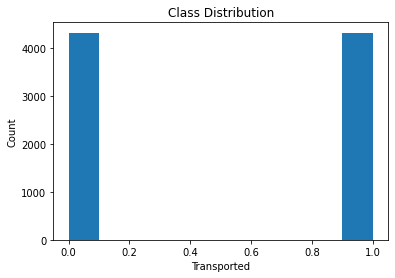

In [14]:
import matplotlib.pyplot as plt

# Visualize the distribution of the target column
plt.hist(df_balanced['Transported'])
plt.xlabel('Transported')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()

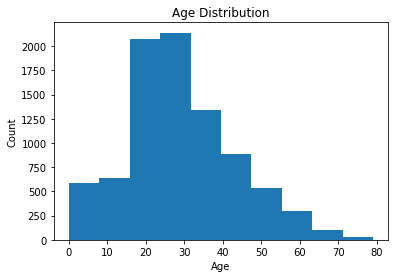

In [15]:
# Visualize the distribution of a feature column
plt.hist(df_balanced['Age'])
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution')
plt.show()

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


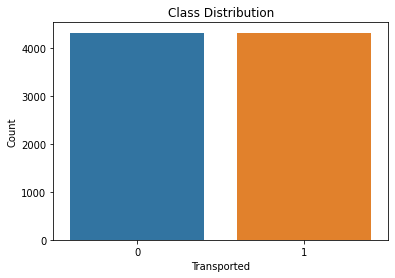

In [16]:
import seaborn as sns

sns.countplot(df_balanced['Transported'])
plt.xlabel('Transported')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()


uncoment to diplay the plot

In [17]:
# sns.pairplot(df_balanced)
# plt.show()


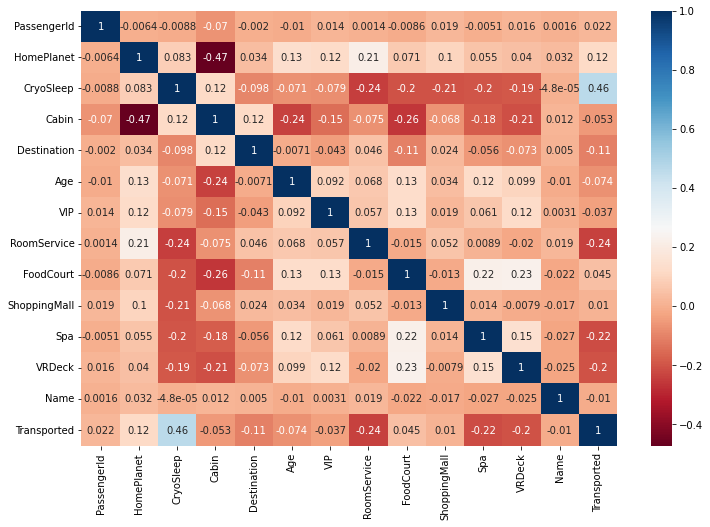

In [18]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_balanced.corr(), cmap='RdBu', annot=True)
plt.show()


In [19]:
from sklearn.model_selection import train_test_split


In [20]:
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Define the models to test
models = ['random_forest', 'gradient_boosting']

# Create a dictionary to store the trained models and their accuracies
trained_models = {}

# Split the DataFrame into X (features) and y (target)
X = df_balanced.drop('Transported', axis=1)
y = df_balanced['Transported']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0,stratify=y)

# Train and evaluate each model
for model_type in models:
  if model_type == 'random_forest':
    model = RandomForestClassifier()
  elif model_type == 'gradient_boosting':
    model = GradientBoostingClassifier()
  model.fit(X_train, y_train)
  
  # Evaluate the model on the test data and store the results
  y_pred = model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  trained_models[model_type] = {'model': model, 'accuracy': accuracy}

# Print the results
for model_type, model_dict in trained_models.items():
  print(f'{model_type}: {model_dict["accuracy"]:.3f}')


random_forest: 0.789
gradient_boosting: 0.788


In [21]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

# Define the parameter grid for the grid search
param_grid = {'learning_rate': [0.1, 0.01, 0.001],
              'max_depth': [3, 5, 7],
              'n_estimators': [100, 500, 1000]}

# Create a gradient boosting classifier
gbc = GradientBoostingClassifier()

# Create a grid search object with 5-fold cross-validation
grid_search = GridSearchCV(estimator=gbc, param_grid=param_grid, cv=5,verbose=2)

# Fit the grid search object to the training data
grid_search.fit(X_train, y_train)

# Get the best hyperparameters and the best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f'Best hyperparameters: {best_params}')
print(f'Best score: {best_score}')


Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END ...learning_rate=0.1, max_depth=3, n_estimators=100; total time=   0.9s
[CV] END ...learning_rate=0.1, max_depth=3, n_estimators=100; total time=   1.0s
[CV] END ...learning_rate=0.1, max_depth=3, n_estimators=100; total time=   0.9s
[CV] END ...learning_rate=0.1, max_depth=3, n_estimators=100; total time=   0.9s
[CV] END ...learning_rate=0.1, max_depth=3, n_estimators=100; total time=   1.2s
[CV] END ...learning_rate=0.1, max_depth=3, n_estimators=500; total time=   4.7s
[CV] END ...learning_rate=0.1, max_depth=3, n_estimators=500; total time=   4.7s
[CV] END ...learning_rate=0.1, max_depth=3, n_estimators=500; total time=   5.3s
[CV] END ...learning_rate=0.1, max_depth=3, n_estimators=500; total time=   4.7s
[CV] END ...learning_rate=0.1, max_depth=3, n_estimators=500; total time=   4.9s
[CV] END ..learning_rate=0.1, max_depth=3, n_estimators=1000; total time=   9.6s
[CV] END ..learning_rate=0.1, max_depth=3, n_es

In [22]:
# Retrain the model with the best hyperparameters
gbc = GradientBoostingClassifier(**best_params)
gbc.fit(X_train, y_train)

# Make predictions on the test set
y_pred = gbc.predict(X_test)

# Evaluate the model on the test set
accuracy = accuracy_score(y_test, y_pred)
print(f'Test set accuracy: {accuracy}')


Test set accuracy: 0.7882298424467099


In [23]:
df_test = pd.read_csv('/kaggle/input/spaceship-titanic/test.csv')

In [24]:
df_test

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4272,9266_02,Earth,True,G/1496/S,TRAPPIST-1e,34.0,False,0.0,0.0,0.0,0.0,0.0,Jeron Peter
4273,9269_01,Earth,False,NaN,TRAPPIST-1e,42.0,False,0.0,847.0,17.0,10.0,144.0,Matty Scheron
4274,9271_01,Mars,True,D/296/P,55 Cancri e,NaN,False,0.0,0.0,0.0,0.0,0.0,Jayrin Pore
4275,9273_01,Europa,False,D/297/P,NaN,NaN,False,0.0,2680.0,0.0,0.0,523.0,Kitakan Conale


In [25]:
import pandas as pd

# Load the test data
df_test =X_test

# Make predictions on the test data using the trained model
y_pred = model.predict(df_test)

# Create a submission DataFrame with the passenger IDs and the predictions
submission = pd.DataFrame({'PassengerId': df_test['PassengerId'], 'Transported': y_pred})

# Write the submission DataFrame to a CSV file
submission.to_csv('submission.csv', index=False)
